# Notebook 15 – Overfitting & Underfitting (Simple Version)

**Big idea:** a model must work on **new data it has never seen**, not just on the data it learned from.

* **Underfitting** – the model is **too simple** and misses the pattern.
* **Overfitting** – the model is **too complex** and memorises the training data (including its noise), so it fails on new data.
* **Good fit** – just right.
**Dataset:** `data.csv` – sales of an online gift shop. 
* **Task:** predict an invoice's **total amount (£)** from `n_items` and `total_qty`.

## Step 1 – Load and prepare the data

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
rmse = lambda y, p: np.sqrt(mean_squared_error(y, p))    
df = pd.read_csv("data.csv", encoding="ISO-8859-1", dtype={"InvoiceNo": str, "StockCode": str})
sales = df[~df.InvoiceNo.str.startswith("C") & (df.Quantity > 0) & (df.UnitPrice > 0)].copy()
sales["Amount"] = sales.Quantity * sales.UnitPrice
inv = sales.groupby("InvoiceNo").agg(n_items=("StockCode", "count"), total_qty=("Quantity", "sum"), amount=("Amount", "sum"))
inv = inv[inv.amount < 5000]                 
FEATURES = ["n_items", "total_qty"]

## Step 2 – Training, Validation and Test sets

| Set | Analogy | Used for | Its error is called |
|---|---|---|---|
| **Training set** | Practice questions | Model **learns** from it | **Training error** |
| **Validation set** | Mock exam | **Choose** the best model/settings | **Validation error** |
| **Test set** | Final exam | One **final honest score** | **Test error** |

We give the model only **200 training invoices** on purpose – overfitting shows up most when data is small.

In [2]:
pool, rest = train_test_split(inv, test_size=0.4, random_state=1)
val, test  = train_test_split(rest, test_size=0.5, random_state=1)
train = pool.sample(200, random_state=0)                    # a small training set
print("Training:", len(train), "| Validation:", len(val), "| Test:", len(test))

Training: 200 | Validation: 3955 | Test: 3955


## Step 3 – Underfitting vs Good fit vs Overfitting

**Model complexity** = how flexible the model is. For a **decision tree**, it is the **depth** (how many questions it may ask):
* **depth 1** – one question → very simple → should *underfit*
* **depth 4** – a few questions → moderate → hopefully a *good fit*
* **depth 20** – many questions → can memorise every training invoice → should *overfit*

In [3]:
def fit_tree(depth, data=train, **kw):
    return DecisionTreeRegressor(max_depth=depth, random_state=0, **kw).fit(data[FEATURES], data.amount)
rows = {}
for name, d in [("Underfit (depth 1)", 1), ("Good fit (depth 4)", 4), ("Overfit (depth 20)", 20)]:
    m = fit_tree(d)
    rows[name] = [rmse(train.amount, m.predict(train[FEATURES])), rmse(val.amount, m.predict(val[FEATURES]))]
pd.DataFrame(rows, index=["Training error (£)", "Validation error (£)"]).T.round(0)

,Training error (£),Validation error (£)
Underfit (depth 1),264.0,472.0
Good fit (depth 4),170.0,405.0
Overfit (depth 20),17.0,446.0


**Reading the table**
* **Underfit:** training error **and** validation error are both high → too simple.
* **Good fit:** the **lowest validation error** → learned the real pattern.
* **Overfit:** training error is almost **zero** (it memorised the 200 invoices), but validation error is **worse than the good fit** → it learned noise.

| Training error | Validation error | Diagnosis |
|---|---|---|
| High | High | **Underfitting** |
| Very low | Much higher (big gap) | **Overfitting** |
| Low | Low and close | **Good fit** |

### Plot 1 – The overfit model memorised its training data
Each dot is one invoice: actual amount (x) vs the model's prediction (y). Dots on the red line = perfect.

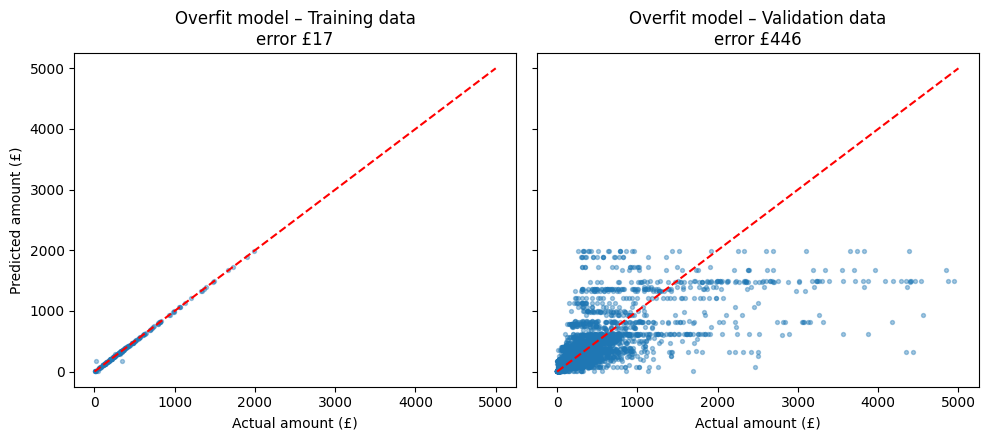

In [4]:
m = fit_tree(20)                                            # the overfit model
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for ax, data, label in [(axes[0], train, "Training data"), (axes[1], val, "Validation data")]:
    ax.scatter(data.amount, m.predict(data[FEATURES]), s=8, alpha=0.4)
    ax.plot([0, 5000], [0, 5000], "r--")
    ax.set_title(f"Overfit model – {label}\nerror £{rmse(data.amount, m.predict(data[FEATURES])):.0f}")
    ax.set_xlabel("Actual amount (£)")
axes[0].set_ylabel("Predicted amount (£)")
plt.tight_layout(); plt.show()

On the **training** data every dot sits exactly on the red line (perfect – because it memorised those invoices). On **new** (validation) data the dots are scattered again. A perfect training score was an illusion.

---
## Step 4 – Model complexity curve (and the Test set)

Now try **every depth from 1 to 20**, and pick the depth with the **lowest validation error**.

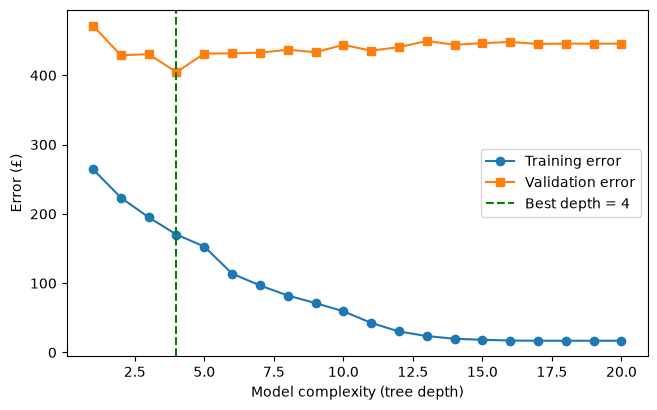

Best depth 4 -> Training £170 | Validation £405 | Test £374


In [4]:
depths = range(1, 21)
train_err = [rmse(train.amount, fit_tree(d).predict(train[FEATURES])) for d in depths]
val_err   = [rmse(val.amount,   fit_tree(d).predict(val[FEATURES]))   for d in depths]
best_depth = list(depths)[int(np.argmin(val_err))]
plt.figure(figsize=(7.5, 4.5))
plt.plot(depths, train_err, "o-", label="Training error")
plt.plot(depths, val_err, "s-", label="Validation error")
plt.axvline(best_depth, color="green", linestyle="--", label=f"Best depth = {best_depth}")
plt.xlabel("Model complexity (tree depth)"); plt.ylabel("Error (£)"); plt.legend(); plt.show()
final = fit_tree(best_depth)
print(f"Best depth {best_depth} -> Training £{rmse(train.amount, final.predict(train[FEATURES])):.0f} | "
      f"Validation £{rmse(val.amount, final.predict(val[FEATURES])):.0f} | "
      f"Test £{rmse(test.amount, final.predict(test[FEATURES])):.0f}")

### Plot 2 – how to read it
* **Training error keeps falling** as the model gets more complex (it can always memorise more).
* **Validation error falls, then rises.** It is lowest at depth **4**, then creeps back up. The gap between the two lines keeps growing.
* **Left of the best depth = underfitting. Right of it = overfitting.**

*(The dip is gentle because real invoices are noisy. The exact best depth also shifts a little with which 200 invoices we train on – in our checks about 3 to 8 – but the pattern stays the same.)*

**Test error:** we picked the depth using the *validation* set, so the *test* set is still untouched and gives the honest final score (about £374). Validation and test errors are close, so we can trust that number. **Never choose your model using the test set.**

## Step 5 – Bias and Variance

These two explain *why* underfitting and overfitting happen.

| | Meaning | Dart-board picture | Linked to |
|---|---|---|---|
| **Bias** | Error from a model that is **too simple** – consistently wrong in the same direction | Darts land far from the bullseye | **Underfitting** |
| **Variance** | Error from a model that is **too sensitive** – its answer changes a lot when the training data changes | Darts scattered everywhere | **Overfitting** |

**Quick experiment:** train each model on **30 different random samples of 200 invoices**, and predict the same validation invoices every time.
* **Bias** = how far the *average* prediction is from the real amount
* **Variance (spread)** = how much the 30 predictions *differ from each other*

In [6]:
rng = np.random.default_rng(0)
samples = [pool.sample(200, random_state=int(rng.integers(1e9))) for _ in range(30)]   # 30 different training sets

rows = {}
for name, d in [("Underfit (depth 1)", 1), ("Good fit (depth 4)", 4), ("Overfit (depth 20)", 20)]:
    preds = np.array([fit_tree(d, s).predict(val[FEATURES]) for s in samples])          # 30 sets of predictions
    rows[name] = [rmse(val.amount, preds.mean(axis=0)), preds.std(axis=0).mean()]

pd.DataFrame(rows, index=["Bias (£)", "Variance / spread (£)"]).T.round(0)

,Bias (£),Variance / spread (£)
Underfit (depth 1),408.0,135.0
Good fit (depth 4),314.0,151.0
Overfit (depth 20),308.0,215.0


**Reading the table**
* **Underfit (depth 1):** the **highest bias** (£408) but the **lowest variance** (£135). It gives almost the same answer whatever data it sees, but that answer is consistently wrong.
* **Good fit (depth 4):** bias drops to £314, variance rises a little (£151).
* **Overfit (depth 20):** bias hardly improves (£308) but **variance jumps to £215** – its predictions change the most depending on which 200 invoices it trained on.

*(Both columns are large because real invoice amounts are noisy. Focus on how the numbers **change between rows**.)*

## Step 6 – The Bias–Variance Tradeoff

* **Simple model** → high bias, low variance → **underfits**
* **Complex model** → low bias, high variance → **overfits**
* Making a model more complex **lowers bias but raises variance**, so you can't minimise both. The best model is at the **balance point** where the total error is smallest.

`Total error = Bias² + Variance + unavoidable noise`


## Step 7 – Regularization (Introduction)

**What is it?** Deliberately **holding a model back** so it can't become too complex. It is the main cure for overfitting.

| Model | How regularization is done |
|---|---|
| **Decision tree** | Limit the depth, or require at least *N* invoices in each leaf (`min_samples_leaf`) |
| **Linear / logistic regression** | Add a **penalty on large coefficients**: **Ridge (L2)** shrinks them, **Lasso (L1)** can shrink some to exactly 0 |
| **Neural network** | Dropout, weight decay, early stopping |

For linear models: `Loss = Prediction error + alpha × (size of the coefficients)` – a bigger `alpha` means a simpler model.

**Why use it?** It gives up a little training accuracy to get better accuracy on new data.

**Demo:** take the overfit tree and force every leaf to hold at least *N* invoices.

In [7]:
rows = {}
for n_leaf in [1, 5, 20, 80]:
    m = DecisionTreeRegressor(min_samples_leaf=n_leaf, random_state=0).fit(train[FEATURES], train.amount)
    rows[n_leaf] = [rmse(train.amount, m.predict(train[FEATURES])), rmse(val.amount, m.predict(val[FEATURES]))]

pd.DataFrame(rows, index=["Training error (£)", "Validation error (£)"]).T.rename_axis("min_samples_leaf").round(0)

,Training error (£),Validation error (£)
min_samples_leaf,,
1,17.0,446.0
5,182.0,418.0
20,234.0,457.0
80,297.0,507.0
